# Density diagnostic trends

An analytic exploration of the trends in empirically derived density versus critical density for diagnostic ratios, as a function of the density fluctuation PDF. Inspired by my prior work on theoretical PDFs for H II regions and the empirical trend described in the Eduardo/Christophe draft paper.

## Toy model of density diagnostic ratios

### Emission of a single line

In the 2-level approximation, the volumetric emission coefficient of a line $k$ can be written: 
$$
j_k = \frac{\epsilon_k}{4\pi} \frac{n_\text{ion} n_\text{e}}{1 + n_\text{e}/n_k}
\quad \mathrm{erg\ s^{-1}\ cm^{-3}\ sr^{-1}}
\tag{DDR-1}
$$

* $\epsilon_k = A_{ul}\, h \nu$ is the per-ion emissivity in the low-density limit
* $n_\text{ion}$ is the number density of the emitting ion
* $n_\text{e}$ is the electron density. From now on, we assume H is fully ionized and ignore the He correction to set $n_\text{e} \approx n$, where $n$ is the H number density.
* $n_k$ is the critical density, where spontaneous radiative decay rate equals collisional deexcitation rate in the 2-level approximation. In general, $n_k \sim T^{1/2}$ but we assume constant $T$.

### Line ratio

If the density $n$ is constant, the ratio of two lines $k = 1, 2$ of a density-sensitive doublet can therefore be written
$$
R_{12} = R_\text{lo} \frac{1 + n / n_1}{1 + n / n_2} \tag{DDR-2}
$$
where $R_\text{lo} = \epsilon_1 / \epsilon_2$ is the low-density limit of the ratio.

To simplify the notation, we define the following:
* Normalized line ratio, $\tilde{R} \equiv R_{12} / R_\text{lo}$
* Geometric mean of the two critical densities, $\bar{n}_\text{g} \equiv (n_1 n_2)^{1/2}$. This is the same as the "maximum-sensitivity density, $n_\mathcal{M}$" defined by Eduardo and Christophe. ***TODO: check that this is true***
* Ratio of the two critical densities, $\delta^2 \equiv n_2 / n_1$
* Normalized density, $\tilde{n} \equiv n / \bar{n}_\text{g}$

In terms of these, we can rewrite the previous equation as
$$
\tilde{R} = \frac{1 + \delta^{-1}\, \tilde{n}}{1 + \delta\, \tilde{n}}. \tag{DDR-3}
$$
The normalized ratio decreases monotonically from $R = 1$ at low density to $R = \delta^{-2}$ at high density. 

The inverse relation is 
$$
\tilde{n} = \frac{1 - \tilde{R}} {\delta\, \tilde{R} - \delta^{-1}}, \tag{DDR-4}
$$
which gives the derived density in terms of the observed ratio.

#### Implementation of dimensionless ratio

In [1]:
class DimensionlessRatio:
    """
    Normalized line ratio from density-sensitive doublet
    """
    def __init__(self, delta=2.0):
        """
        delta is the sqrt of ratio of the two critical densities
        """
        self.delta = delta

    def __call__(self, ntilde):
        """Normalized line ratio as a function of normalized density"""
        return (1 + ntilde / self.delta) / (1 + ntilde * self.delta)

    def ntilde(self, R):
        "Inverse function giving normalized density from normalized ratio"
        return (1 - R) / (self.delta * R - (1 / self.delta))
        

In [2]:
R = DimensionlessRatio()

In [3]:
R(1)

0.5

In [4]:
R.ntilde(0.5)

1.0

In [5]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_context("talk")

##### Example of optical nebular lines with moderate contrast, $\delta^2 = 3.4$

In [6]:
n_arr = np.geomspace(0.001, 1000)
Rtilde = DimensionlessRatio(3.4**0.5)

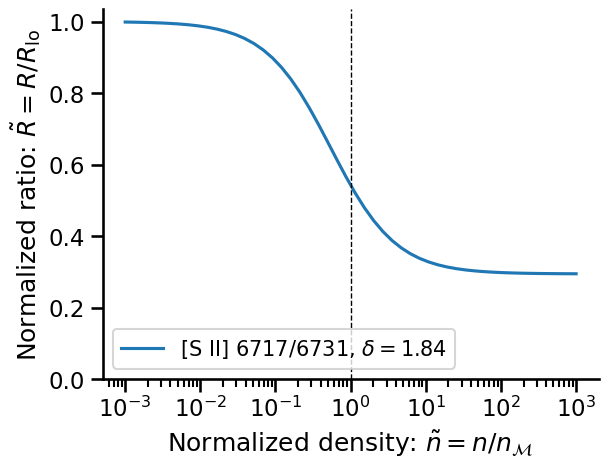

In [7]:
fig, ax = plt.subplots()
ax.plot(n_arr, Rtilde(n_arr), label=fr"[S II] 6717/6731, $\delta = {Rtilde.delta:.2f}$")
ax.axvline(1.0, color="k", lw=1, ls="dashed")
ax.set_xscale("log")
ax.set_ylim([0, None])
ax.legend(fontsize="small")
ax.set_xlabel(r"Normalized density: $\tilde{n} = n / n_\mathcal{M}$")
ax.set_ylabel(r"Normalized ratio: $\tilde{R} = R / R_\mathrm{lo}$")
sns.despine()

##### Example of NUV forbidden/semi-forbidden lines with large contrast, $\delta^2 \approx 10^4$.

*Note that I haven't checked what the exact value of $\delta$ is for 1907/1909 but Osterbrock & Ferland give Rlo / Rhi = 1.53 / 9e-5, which implies $\delta \approx 130$*

In [8]:
n_arr = np.geomspace(1e-5, 1e5)
Rtilde = DimensionlessRatio(delta=(1.53 / 9e-5)**0.5)

First, with a linear y scale.

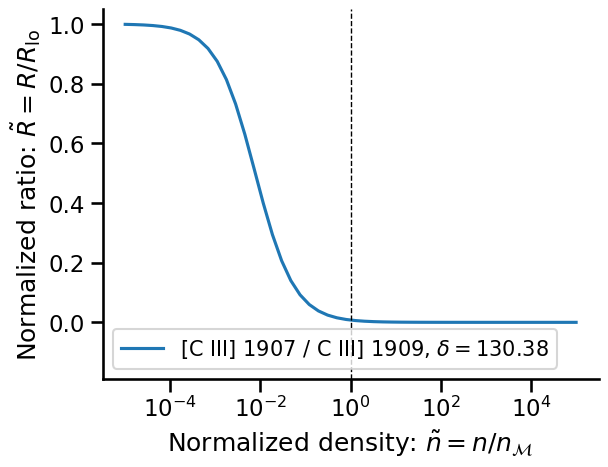

In [9]:
fig, ax = plt.subplots()
ax.plot(n_arr, Rtilde(n_arr), label=fr"[C III] 1907 / C III] 1909, $\delta = {Rtilde.delta:.2f}$")
ax.axvline(1.0, color="k", lw=1, ls="dashed")
ax.set_xscale("log")
ax.set_yscale("linear")
ax.set_ylim([-0.19, None])
ax.legend(fontsize="small")
ax.set_xlabel(r"Normalized density: $\tilde{n} = n / n_\mathcal{M}$")
ax.set_ylabel(r"Normalized ratio: $\tilde{R} = R / R_\mathrm{lo}$")
sns.despine()

Note that the maximum in *semi-logarithmic* sensitivity $d R / d \ln n$ is at a density about 100 times lower than $n_\mathcal{M}$. 

Now the same, but with a log y scale.

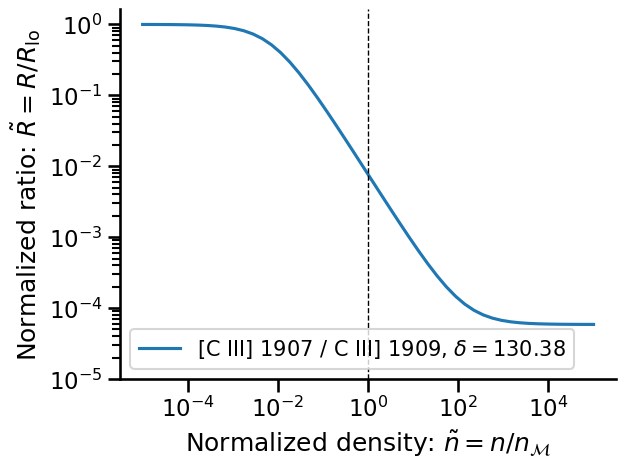

In [10]:
fig, ax = plt.subplots()
ax.plot(n_arr, Rtilde(n_arr), label=fr"[C III] 1907 / C III] 1909, $\delta = {Rtilde.delta:.2f}$")
ax.axvline(1.0, color="k", lw=1, ls="dashed")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim([1e-5, None])
ax.legend(fontsize="small")
ax.set_xlabel(r"Normalized density: $\tilde{n} = n / n_\mathcal{M}$")
ax.set_ylabel(r"Normalized ratio: $\tilde{R} = R / R_\mathrm{lo}$")
sns.despine()

This seems to confirm that $n_\mathcal{M} = \bar{n}_\text{g}$, since $n_\mathcal{M}$ is defined as the density where the *fully logarithmic* sensitivity $d \ln R / d \ln n$ is maximum. Also, it shows that when $\delta \gg 1$ there is a large density range of near-optimal sensitivity. However, I suspect that the high-density range with $\tilde{R} < 0.01$ will not be very useful, since the forbidden line may be too weak to observe easily. 

## Integration over the $n$-PDF

For the variety of PDF, we will use the emission-weighted density histogram $H_n$ (as in the other notebook on photoevaporation flows). The emission in question is of an idealized recombination line with emissivity proportional to $n^2$, so we have
$$
\int_0^\infty H_n \,dn = \int_{\mathcal{V}} n^2 \,dV \equiv \text{Volume Emission Measure (VEM)}, \tag{PDF-1}
$$
so $H_n$ is similar to the *Differential Emission Measure* (DEM) used in X-ray astronomy, but as a function of density instead of temperature.

***I am pretty sure that this is the same definition that Eduardo and Christophe are using for their $p(n_e)$***

The total luminosity of a line is then given by 
$$
L_k = \int_{\mathcal{V}} 4\pi j_k \, dV 
= \epsilon_k \int_0^\infty \frac{H_n}{1 + n / n_k} \, dn, \tag{PDF-2}
$$
so by the results of the first section the normalized line ratio of the integrated spectrum is
$$
\tilde{R} = \frac{\int_0^\infty (1 + \delta\,\tilde{n})^{-1}\, H_\tilde{n} \, d\tilde{n}}{\int_0^\infty (1 + \delta^{-1}\,\tilde{n})^{-1}\, H_\tilde{n} \, d\tilde{n}}. \tag{PDF-3}
$$
Recall that $\tilde{n} = n / n_\mathcal{M}$ (switching to Eduardo's notation, now I am sure that $n_\mathcal{M} = \bar{n}_\text{g}$).

### Power-law density PDFs

We first consider the simple case of a power-law PDF between lower density bound $n_\min$ and upper density bound $n_\max$: 
$$
H_n = A\, n^m \quad \text{for} \quad n_\min < n < n_\max, \tag{PL-1}
$$
where $A = (m + 1) \, \text{VEM} \, / \, (n_\max^{m+1} - n_\min^{m+1})$ is a normalization constant, defined by the integral constraint of eq. (PDF-1). For the special case of $m = -1$ we have instead: $A = \text{VEM} \, / \, \ln(n_\max/n_\min)$. But for the purposes of line ratios, it does not matter what $A$ is since it always cancels.

This form of PDF is found, for example, for a constant-velocity wind: $m = -1/2$ in spherical geometry and $m = -1$ in cylindical geometry. These are a crude approximations to the ionized photoevaporation flow from a molecular globule of filament, respectively. In general, H~II regions will be a combination of many such flows, plus the interactions between them, wind-driven shells, etc. The most appropriate value of $m$ is not obvious a priori, so we will leave it as a free parameter. 

For general $m$, the integrals can be found in terms of the hypergeometric function $_2F^1(a, b; c; z)$, but for integer and half-integer $m$ the solution can be written in terms of elementary functions, so we will consider some particular cases first.

#### Flat PDF, $m = 0$

In this case the solution is
$$
\tilde{R}(m=0, n_\min, n_\max;\, n_\mathcal{M}, \delta) \ = \ \delta^{-2} \, 
\frac{
    \ln\left[ \displaystyle
    \frac{n_\mathcal{M} + \delta\, n_\max}{n_\mathcal{M} + \delta\, n_\min} 
    \right]
}{
    \ln\left[ \displaystyle
    \frac{n_\mathcal{M} + \delta^{-1}\, n_\max}{n_\mathcal{M} + \delta^{-1}\, n_\min} 
    \right]
},
\tag{PL-2}
$$
where we give the normalized line ratio $\tilde{R}(m, n_\min, n_\max;\, n_\mathcal{M}, \delta)$ in terms of physical densities, explicitly distinguishing the parameters of the $n$-PDF (before the semi-colon) and of the diagnostic line pair (after the semi-colon).

#### Spherical wind, $m = -1/2$

In this case the solution is
$$
\tilde{R}(m=-1/2, n_\min, n_\max;\, n_\mathcal{M}, \delta) \ = \ \delta^{-1} \, 
\frac{
    \arctan(\delta\, n_\max / n_\mathcal{M})^{1/2} 
    - \arctan(\delta\, n_\min / n_\mathcal{M})^{1/2}
}{
    \arctan(\delta^{-1}\, n_\max / n_\mathcal{M})^{1/2} 
    - \arctan(\delta^{-1}\, n_\min / n_\mathcal{M})^{1/2}
},
\tag{PL-3}
$$

#### Cylindrical wind, $m = -1$

Also has $\ln$ functions but I can't be bothered with it ...

#### General $m$

The general solution is
$$
\tilde{R}(m, n_\min, n_\max;\, n_\mathcal{M}, \delta) \ = 
\frac{
    n_\max^{m+1}\, \mathcal{F}(m, \delta\, n_\max / n_\mathcal{M}) 
    - n_\min^{m+1}\, \mathcal{F}(m, \delta\, n_\min / n_\mathcal{M})
}{
    n_\max^{m+1}\, \mathcal{F}(m, \delta^{-1}\, n_\max / n_\mathcal{M})
    - n_\min^{m+1}\, \mathcal{F}(m, \delta^{-1}\, n_\min / n_\mathcal{M})
},
\tag{PL-4}
$$
where
$$
\mathcal{F}(m, x) \equiv {}_2F_1(1, m+1; m+2; -x) \tag{PL-5}
$$
and ${}_2F_1(\cdots)$ is the hypergeometric function: `scipy.special.hyp2f1()`.

So, written like this, the general solution is no more complex than the special cases. The only advantage of the special cases is that they use elementary functions, but it is impossible (for me) to tell what the graphs will look like just from looking at the equations, so that is not much help. 

Therefore I will first implement the general case, and then maybe use a special case as a cross-check.

### Implementation of power-law PDF

In [104]:
from scipy.special import hyp2f1

class PowerLawPDF:
    """
    Power-law density PDF with upper and lower bounds
    """
    def __init__(self, m, nmin, nmax):
        """
        Parameters: slope `m`, density bounds `nmin`, `nmax`
        """
        self.m = m
        self.nmin = nmin
        self.nmax = nmax
        # Calculate normalization with respect to VEM
        if m == -1:
            self.A = 1 / np.log(self.nmax / self.nmin)
        else:
            self.A = (self.m + 1) / (self.nmax ** (self.m + 1) - self.nmin ** (self.m + 1))
        self.label = fr"${m=:.2f}$, $n_\min = {nmin:.2g}$, $n_\max = {nmax:.2g}$"

    def __call__(self, n):
        """Evaluate PDF for density `n` (may be scalar or array)"""
        return np.where(
            (n >= self.nmin) & (n <= self.nmax),
            self.A * n ** self.m,
            np.nan
        )

    def F(self, x):
        """Particular case of the Gaussian hypergeometric function that we need for the integrals"""
        # Note that hyp2f1 has a bug for the case of m = -1, where it returns NaNs
        return hyp2f1(1, self.m + 1, self.m + 2, -x)

    def stats(self):
        """
        Calculate different measures of the central density (variously weighted means and medians) and
        the distribution width (stddev, clumping, intercentile range)
        """
        # TODO
        ...

    def ncentile(self, p, weighting: Literal["emission", "volume"] = "emission"):
        """
        Calculate the `p`-percentile (0-100) of a bounded power-law distribution

        Options for volume or emission (default) weighting
        """
        s = self.m - 2 if weighting == "volume" else self.m
        f = p / 100
        if s == -1.0:
            return self.nmin ** (1.0 - f) * self.nmax ** f
        else:
            sp1 = s + 1
            return ((1.0 - f) * self.nmin ** sp1 + f * self.nmax ** sp1) ** (1 / sp1)



Example of PDF with $m = -0.25$

In [12]:
pdf = PowerLawPDF(-0.25, 1.0, 1.0e5)
n_arr = np.geomspace(0.1, 1e6, 500)
Hn = pdf(n_arr)

Plot on semi-log scale for comparison with Eduardo/Christophe's PDF

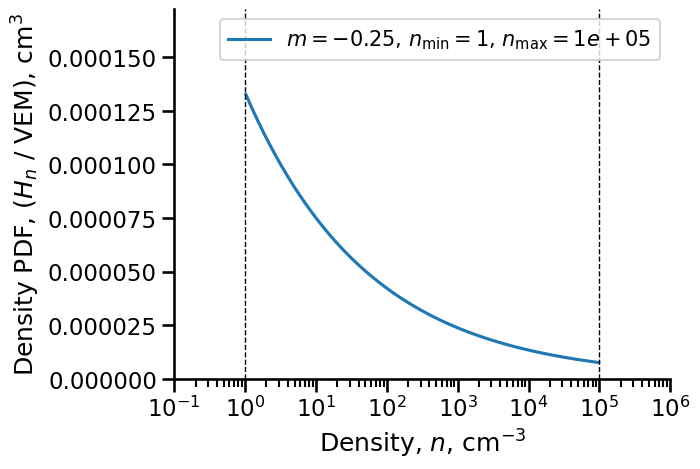

In [13]:
fig, ax = plt.subplots()
ax.plot(n_arr, Hn, label=pdf.label)
for x in pdf.nmin, pdf.nmax:
    ax.axvline(x, lw=1, ls="dashed", color="k")
ax.legend(fontsize="small")
ax.set_xscale("log")
ax.set_ylim(0.0, 1.3 * np.nanmax(Hn))
ax.set_xlim(np.min(n_arr), np.max(n_arr))
ax.set_xlabel("Density, $n$, cm$^{-3}$")
ax.set_ylabel(r"Density PDF, $(H_n \ / \ \mathrm{VEM})$, cm$^3$")

sns.despine()

This looks fine. It seems that it might integrate to unity, which it ought to if I have the normalization right. 

Note that although this looks like it is concentrated at the low-density end, it really is not. If we plot the *Densimetric Energy Distribution* $n H_n$ on a log-log scale, then it looks quite different:

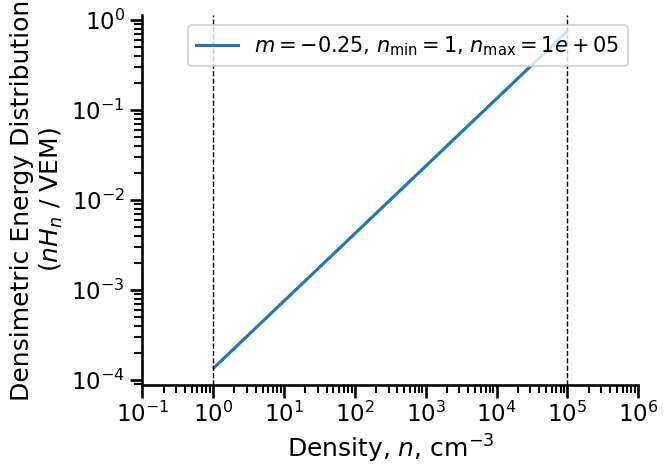

In [14]:
fig, ax = plt.subplots()
ax.plot(n_arr, n_arr * Hn, label=pdf.label)
for x in pdf.nmin, pdf.nmax:
    ax.axvline(x, lw=1, ls="dashed", color="k")
ax.legend(fontsize="small")
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim(0.0, 1.3 * np.nanmax(Hn))
ax.set_xlim(np.min(n_arr), np.max(n_arr))
ax.set_xlabel("Density, $n$, cm$^{-3}$")
ax.set_ylabel("Densimetric Energy Distribution\n" + r"$(n H_n \ / \ \mathrm{VEM})$")

sns.despine()

It turns out that shallow slopes like this do not work. 

Repeat but for the possible best-fit parameters I find below, which is a much steeper slope: $m = -1.3$

In [15]:
pdf = PowerLawPDF(-1.3, 10**1.3, 10**6.5)
n_arr = np.geomspace(0.1, 1e7, 500)
Hn = pdf(n_arr)

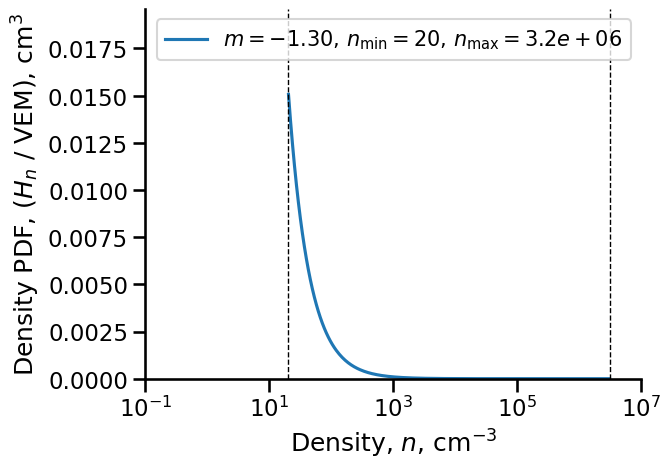

In [16]:
fig, ax = plt.subplots()
ax.plot(n_arr, Hn, label=pdf.label)
for x in pdf.nmin, pdf.nmax:
    ax.axvline(x, lw=1, ls="dashed", color="k")
ax.legend(fontsize="small")
ax.set_xscale("log")
ax.set_ylim(0.0, 1.3 * np.nanmax(Hn))
ax.set_xlim(np.min(n_arr), np.max(n_arr))
ax.set_xlabel("Density, $n$, cm$^{-3}$")
ax.set_ylabel(r"Density PDF, $(H_n \ / \ \mathrm{VEM})$, cm$^3$")

sns.despine()

The semi-log way of plotting it is very misleading begause it looks to be overwhelmingly biased to the low-density cut-off, but this is not really true since the apparent peak at n < 1e3 represents a tiny fraction of the density range, so gets significantly diluted.

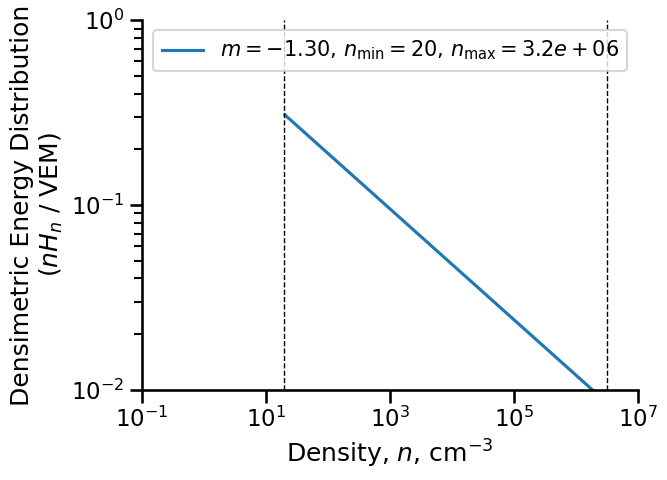

In [17]:
fig, ax = plt.subplots()
ax.plot(n_arr, n_arr * Hn, label=pdf.label)
for x in pdf.nmin, pdf.nmax:
    ax.axvline(x, lw=1, ls="dashed", color="k")
ax.legend(fontsize="small")
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim(0.0, 1.3 * np.nanmax(Hn))
ax.set_xlim(np.min(n_arr), np.max(n_arr))
ax.set_xlabel("Density, $n$, cm$^{-3}$")
ax.set_ylabel("Densimetric Energy Distribution\n" + r"$(n H_n \ / \ \mathrm{VEM})$")
ax.set_ylim(0.01, 1.0)
sns.despine()


This shows that despite the relatively steep slope, we still have a significant fraction of the emission that comes from the high density gas (several percent for n > 1e5). 

### Implementation of concrete line ratios

Define a class for concrete line ratios and test it

In [18]:
class ConcreteRatio:
    """
    A concrete manifestation of the DimensionlessRatio model for a particular line pair

    The difference from DimensionlessRatio is that in addition to the contrast factor `delta`
    we also have a physical density `nM` of max sensitivity and a low-density limit of the line ratio `Rlo`
    (although Rlo is not relevant to the current analysis, so is only useful for plotting). 
    Oh, and we also have an optional label. If unspecified, one is created based on the params.
    """
    def __init__(self, nM, delta, Rlo=1.0, label=None):
        self.delta = delta
        self.nM = nM
        self.Rlo = Rlo
        self.Rhi = Rlo / delta ** 2
        if label is None:
            self.label = f"{nM=:.2e} {delta=:.2f} {Rlo=:.2f}"
        else:
            self.label = label
        self.Rtilde = DimensionlessRatio(delta=delta)

    def __call__(self, n):
        """
        Line ratio as function of physical density `n` (in same units as nM)
        """
        return self.Rlo * self.Rtilde(n / self.nM)

    def n(self, R):
        """
        Inverse function to derive density from line ratio
        """
        return self.nM * self.Rtilde.ntilde(R / self.Rlo)
        

In [19]:
n_arr = np.geomspace(1, 1e5, 500)
Rsii = ConcreteRatio(nM=10**3.06, delta=3.4**0.5, Rlo=1.44, label="[S II] 6716 / 6731")
Roii = ConcreteRatio(nM=10**3.16, delta=(16/3)**0.5, Rlo=1.5, label="[O II] 3727 / 3729")

Check that we can round-trip from densities to ratios and back:

In [20]:
ratios = Rsii(np.array([1e2, 1e3, 1e4]))
Rsii.n(ratios)

array([  100.,  1000., 10000.])

Yes, that works.

Now attempt to reproduce Osterbrock & Ferland Figure 5.8

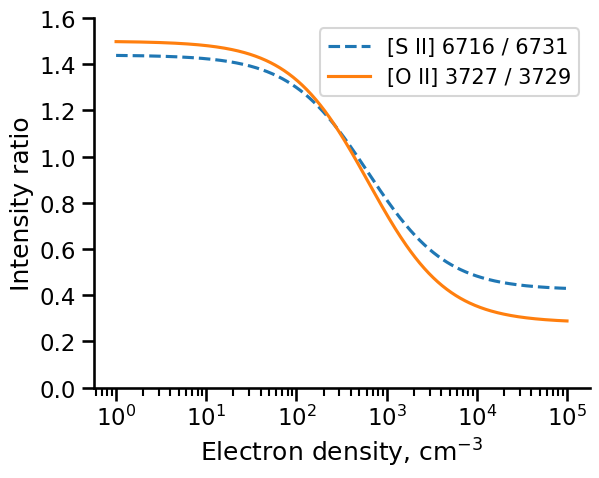

In [21]:
fig, ax = plt.subplots()
ax.plot(n_arr, Rsii(n_arr), ls="dashed", label=Rsii.label)
ax.plot(n_arr, Roii(n_arr), label=Roii.label)
ax.set_ylim(0.0, 1.6)
ax.legend(fontsize="small")
ax.set_xscale("log")
ax.set_xlabel("Electron density, cm$^{-3}$")
ax.set_ylabel("Intensity ratio")
sns.despine()

This is similar, but a bit different to in the book. This seems to be because the values of $n_\mathcal{M}$ that I use here from Table 1 of the draft paper have [O II] with slightly higher value than [S II], whereas in the book it looks like the reverse is true. 

Repeat for NUV lines in Figure 5.11 of Osterbrock & Ferland.

In [22]:
n_arr = np.geomspace(100, 1e7, 500)
Rciii = ConcreteRatio(nM=10**6.7, delta=130, Rlo=1.55, label="[C III] 1907 / C III] 1909")
Rniv = ConcreteRatio(nM=10**7.14, delta=130, Rlo=1.58, label="[N IV] 1483 / N IV] 1487")

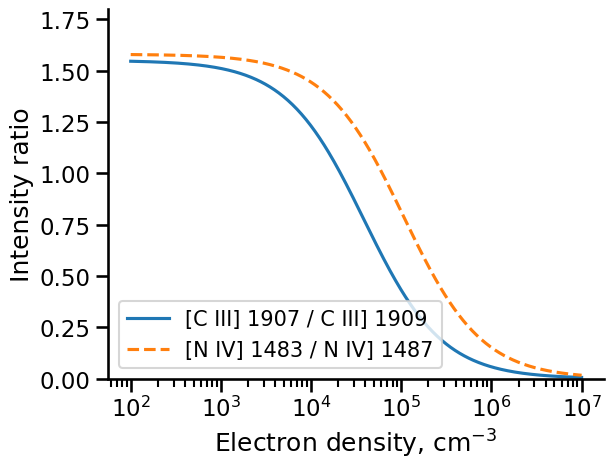

In [23]:
fig, ax = plt.subplots()
ax.plot(n_arr, Rciii(n_arr), label=Rciii.label)
ax.plot(n_arr, Rniv(n_arr), ls="dashed", label=Rniv.label)
ax.set_ylim(0.0, 1.8)
ax.legend(fontsize="small")
ax.set_xscale("log")
ax.set_xlabel("Electron density, cm$^{-3}$")
ax.set_ylabel("Intensity ratio")
sns.despine()

This looks extremely similar, compared with the book, although possibly shifted to somewhat higher densities.

*I should also compare with pyneb*. 

Repeat on log-log scale.

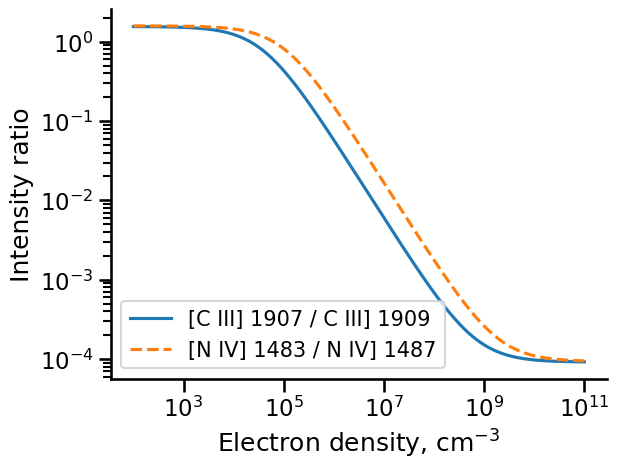

In [24]:
fig, ax = plt.subplots()
n_arr = np.geomspace(100, 1e11, 500)
ax.plot(n_arr, Rciii(n_arr), label=Rciii.label)
ax.plot(n_arr, Rniv(n_arr), ls="dashed", label=Rniv.label)
#ax.set_ylim(0.0, 1.8)
ax.legend(fontsize="small")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Electron density, cm$^{-3}$")
ax.set_ylabel("Intensity ratio")
sns.despine()

### Implementation of PDF-integrated derived densities

In [25]:
def apparent_density_powerlaw(R: ConcreteRatio, pdf: PowerLawPDF):
    """
    Find the apparent derived density from a PDF distribution, using a given line ratio diagnostic 
    """
    d = R.delta
    nm = R.nM
    n1 = pdf.nmin
    n2 = pdf.nmax
    m = pdf.m
    a2 = n2 ** (m + 1)
    a1 = n1 ** (m + 1)
    F = pdf.F
    # This implements equation PL-4 for the general m case
    numerator = a2 * F(d * n2 / nm) - a1 * F(d * n1 / nm)
    denominator = a2 * F(n2 / nm / d) - a1 * F(n1 / nm / d)
    R_apparent = R.Rlo * numerator / denominator
    assert R.Rhi <= R_apparent <= R.Rlo, "Derived ratio is out of bounds"
    # Invert the ratio to get the "observed" density
    return R.n(R_apparent)
    
    

Test it out for the line ratios that we plotted above. Add in the red/blue [O II] ratio to represent an intermediate $n_\mathcal{M}$ case.

In [35]:
Roii_red = ConcreteRatio(nM=10**5.1, delta=10, Rlo=1.0, label="[O II] 7320 / 3727")

In [36]:
pdf = PowerLawPDF(-1.5, 100, 1e8)
print(pdf.label)
print()
for R in [Rsii, Roii, Roii_red, Rciii, Rniv]:
    x, y = np.log10(R.nM), np.log10(apparent_density_powerlaw(R, pdf))
    print(f"{x:.2f}, {y:.2f}, {R.label}")

$m=-1.50$, $n_\min = 1e+02$, $n_\max = 1e+08$

3.06, 2.55, [S II] 6716 / 6731
3.16, 2.58, [O II] 3727 / 3729
5.10, 3.24, [O II] 7320 / 3727
6.70, 3.50, [C III] 1907 / C III] 1909
7.14, 3.71, [N IV] 1483 / N IV] 1487


Looks like power law of $m = -1.5$ works OK. Seems insenitive to the high cutoff, but somewhat sensitive to low cutoff. We need to make graphs to be able to see more clearly though.

Encapsulate the apparent density in an array-valued function:

In [38]:
from numpy.typing import ArrayLike, NDArray
def n_app_from_nM(nM: ArrayLike, pdf: PowerLawPDF, delta: ArrayLike | None = None) ->  NDArray[np.floating]:
    """Vectorized version of apparent density"""
    if delta is None:
        # Vary with nM = 1e3 -> 1e7 as delta = 2 -> 200
        delta = 2.0 * np.sqrt(nM / 1e3)
    else:
        # Promote scalar to vector
        delta = delta * np.ones_like(nM)
    return np.array([
        apparent_density_powerlaw(ConcreteRatio(_nM, delta=_delta), pdf)
        for _nM, _delta in zip(nM, delta)
    ])

Note that the default behavior of this function is for $\delta$ to vary with $n_\mathcal{M}$ as
$$
\frac{\delta}{2} = \left( \frac{n_\mathcal{M}}{1000} \right)^{1/2}
$$
which is just a power-law fit to the difference between the nebular [S II] 6716 / 6731 ratio ($\delta \approx 2$, $n_\mathcal{M} \approx 10^3$) and the [C III] / C III] ratio ($\delta \approx 200$, $n_\mathcal{M} \approx 10^7$). 

Alternatively, $\delta$, can be explicitly passed as a scalar or array.

***TODO*** *Go through all the ratios in Table 1 of the draft paper and calculate their equivalent $\delta$ using pyneb* 

### Observed trend

Define a function for plotting the observed trend:
$$
\log_{10} n_\text{obs} = (0.33 \pm 0.05) \log_{10} n_\mathcal{M} + (1.34 \pm 0.22)
$$

In [37]:
def n_obs_eduardo_fit(nM: ArrayLike, slope: float = 0.33, intercept: float = 1.34) ->  NDArray[np.floating]:
    """
    Observed linear trend (on log-log scale) of line-ratio-derived density against max-sensitivity density 
    of that line ratio (n_M)
    
    Equation (2) from draft paper 2026-06-03. 
    
    Default slope and intercept are from Eduardo's original fit to Orion Nebula LVM median values (N = 16)
    """
    x = np.log10(nM)
    y = intercept + slope * x
    return 10 ** y

We want to convert the uncertainties in the slope and intercept into a confidence region to plot.

#### Centering of the linear fit

It looks like Eduardo reported the fit in the raw uncentered form, so the intercept corresponds to the extrapolated value at $x=0$, but this is far outside the range $\approx [3, 7]$ of the data. This means that the uncertainty on the intercept is large and highly anti-correlated with the uncertainty on the slope. It would be better to center the fitted line near the middle of the data, such as $x_0 = 4.8$, which yields the fit
$$
\log_{10} n_\text{obs} = (0.33 \pm 0.05) (\log_{10} n_\mathcal{M} - 4.8) + (2.93 \pm 0.05)
$$
This gives a more meaningful second coefficient (intercept) and gives the correct hourglass-shaped confidence band.

#### Pruning non-independent ratios from the graph

Not all the line ratios in Table 1 of draft paper are independent. For instance, [S II] has 4 ratios, but only 2 are independent. Also [Fe III] should keep only 3 of 5 ratios, and [O II] keeps 2 of 5.  This cuts down the number of points from $N = 16$ to $N = 9$. This does not significantly change the correlation coefficient ($r = 0.88$, compared with the previous $r = 0.89$), but it does decrease the significance of the correlation ($p = 2 \times 10^{-3}$ versus the previous $3.9 \times 10^{-6}$).  In gaussian-equivalent terms, this is a reduction in significance from $4.6 \sigma$ to $3.1 \sigma$, so still significant but only moderately so. 


I got ChatGPT to extract the data from the figure and repeat the fit using just the 9 independent points, which yielded
$$
\log_{10} n_\text{obs} = (0.328 \pm 0.068) (\log_{10} n_\mathcal{M} - 4.8) + (2.97 \pm 0.081).
$$
So, the slope and the intercept are almost identical, but the uncertainties are about 50% larger.

Make an improved fit function that also calculates the confidence limits

In [102]:
from typing import Literal, get_args

LineType = Literal["value", "upper", "lower"]
_VALID_LINE_TYPES = get_args(LineType)

def n_obs_improved_fit(
    nM: ArrayLike, 
    x0: float = 4.8,
    slope: float = 0.328,
    intercept: float = 2.97,
    e_slope: float = 0.068,
    e_intercept: float = 0.081,
    line_type: LineType = "value",
) ->  NDArray[np.floating]:
    """
    Observed linear trend (on log-log scale) of line-ratio-derived density against max-sensitivity density 
    of that line ratio (n_M)
    
    Inspired by Equation (2) from draft paper but with improvements:
    * Non-independent ratios are pruned, reducing N = 14 data points to N = 9
    * Fitted intercept is centered on the data range (log10 n = 4.8) to reduce correlation with fitted slope
    
    Default slope and intercept are obtaimed from fit to Orion Nebula LVM median values (N = 9)
    """
    if line_type not in _VALID_LINE_TYPES:
        raise ValueError(
            f"Invalid line_type={line_type!r}; "
            f"expected one of {', '.join(_VALID_LINE_TYPES)}"
        )
    x = np.log10(nM)
    y = intercept + slope * (x - x0)
    if line_type in ("upper", "lower"):
        # Calculate confidence bounds
        sig2 = e_intercept ** 2 + (e_slope * (x - x0)) ** 2
        # For 9 independent points the 95% confidence band is +/- 2.365 sigma
        dy = 2.365 * np.sqrt(sig2)
        if line_type == "upper":
            y += dy
        else:
            y -= dy
    return 10 ** y

In [96]:
n_obs_improved_fit([1e3, 1e4, 1e5])

array([ 239.66245294,  510.03502396, 1085.42544931])

In [97]:
n_obs_improved_fit([1e3, 1e4, 1e5], line_type="upper")

array([ 532.99329054,  867.677959  , 1697.64321141])

In [101]:
# UNCOMMENT to test that the function correctly traps invalid argument
# n_obs_improved_fit([1e3, 1e4, 1e5], line_type="mistake")

### Plot predicted density trends

In [49]:
nM_array = np.geomspace(1e3, 1e7)

It looks like the best-fit to the observed trend is found with $m \approx -1.3$ 

#### Sensitivity to power-law slope $m$

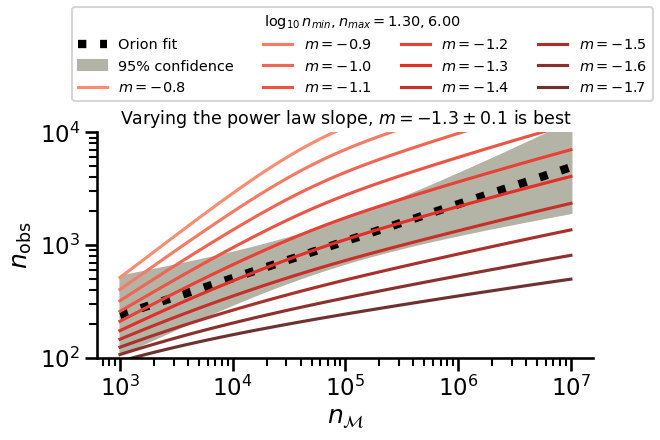

In [86]:
sns.set_palette("Reds_d", 11)
fig, ax = plt.subplots()

# Show empirical fit and 95% confidence band
y_mid = n_obs_improved_fit(nM_array)
y_low = n_obs_improved_fit(nM_array, line_type="lower")
y_high = n_obs_improved_fit(nM_array, line_type="upper")
ax.plot(nM_array, y_mid, color="k", lw=6, ls="dotted", label="Orion fit", zorder=1)
ax.fill_between(nM_array, y_low, y_high, color=(0.7, 0.7, 0.65), label="95% confidence", zorder=0)

nmin, nmax = 20, 1e6
# Note that we want to avoid m = -1 exactly, since thath causes problems, so add 0.001
for m in -0.801 - 0.1 * np.arange(10):
    pdf = PowerLawPDF(m, nmin, nmax)
    ax.plot(nM_array, n_app_from_nM(nM_array, pdf, delta=None), label=fr"$m = {m:.1f}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_aspect("equal")
fig.legend(
    fontsize="xx-small", 
    ncol=4, 
    title_fontsize="xx-small",
    title=rf"$\log_{{10}} n_{{min}}, n_{{max}} = {np.log10(nmin):.2f}, {np.log10(nmax):.2f}$",
)
ax.set_title(r"Varying the power law slope, $m = -1.3 \pm 0.1$ is best", fontsize="x-small")
ax.set_xlabel(r"$n_\mathcal{M}$")
ax.set_ylabel(r"$n_\text{obs}$")
ax.set_ylim(100, 1e4)
sns.despine()

#### Sensitivity to upper density bound $n_\max$

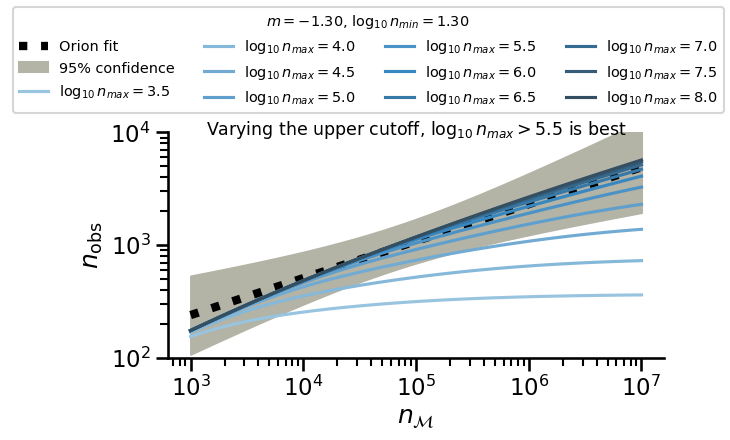

In [85]:
sns.set_palette("Blues_d", 11)
fig, ax = plt.subplots()

# Show empirical fit and 95% confidence band
y_mid = n_obs_improved_fit(nM_array)
y_low = n_obs_improved_fit(nM_array, line_type="lower")
y_high = n_obs_improved_fit(nM_array, line_type="upper")
ax.plot(nM_array, y_mid, color="k", lw=6, ls="dotted", label="Orion fit", zorder=1)
ax.fill_between(nM_array, y_low, y_high, color=(0.7, 0.7, 0.65), label="95% confidence", zorder=0)

nmin = 20
m = -1.3
for nmax in np.logspace(3.5, 8.0, 10):
    pdf = PowerLawPDF(m, nmin, nmax)
    lnmax = np.log10(nmax)
    ax.plot(
        nM_array, 
        n_app_from_nM(nM_array, pdf, delta=None), 
#        lw=1,
        label=fr"$ \log_{{10}} n_{{max}} = {lnmax:.1f}$",
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_aspect("equal")
fig.legend(
    fontsize="xx-small", 
    ncol=4, 
    title_fontsize="xx-small",
    title=rf"$m = {m:.2f}$, $\log_{{10}} n_{{min}} = {np.log10(nmin):.2f}$",
)
ax.set_title(r"Varying the upper cutoff, $\log_{{10}} n_{{max}} > 5.5$ is best", y=0.95, fontsize="x-small")
ax.set_xlabel(r"$n_\mathcal{M}$")
ax.set_ylabel(r"$n_\text{obs}$")
ax.set_ylim(100, 1e4)
sns.despine()

#### Sensitivity to lower density bound $n_\min$

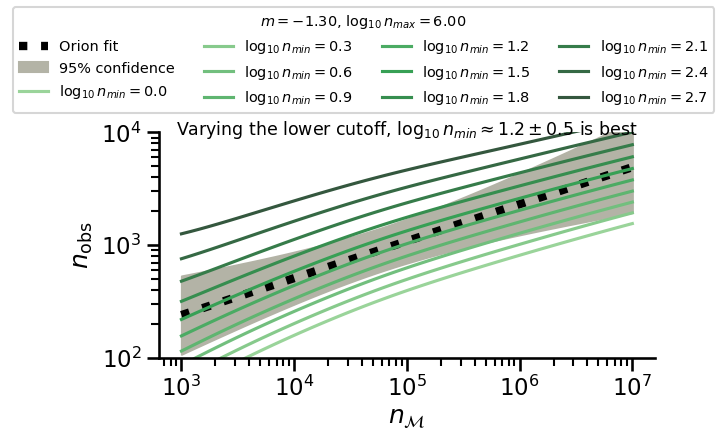

In [84]:
sns.set_palette("Greens_d", 11)
fig, ax = plt.subplots()

# Show empirical fit and 95% confidence band
y_mid = n_obs_improved_fit(nM_array)
y_low = n_obs_improved_fit(nM_array, line_type="lower")
y_high = n_obs_improved_fit(nM_array, line_type="upper")
ax.plot(nM_array, y_mid, color="k", lw=6, ls="dotted", label="Orion fit", zorder=1)
ax.fill_between(nM_array, y_low, y_high, color=(0.7, 0.7, 0.65), label="95% confidence", zorder=0)

nmax = 1.e6
m = -1.3
for nmin in np.logspace(0.0, 2.7, 10):
    pdf = PowerLawPDF(m, nmin, nmax)
    lnmin = np.log10(nmin)
    ax.plot(
        nM_array, 
        n_app_from_nM(nM_array, pdf, delta=None), 
        label=fr"$ \log_{{10}} n_{{min}} = {lnmin:.1f}$",
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_aspect("equal")
fig.legend(
    fontsize="xx-small", 
    ncol=4, 
    title_fontsize="xx-small",
    title=rf"$m = {m:.2f}$, $\log_{{10}} n_{{max}} = {np.log10(nmax):.2f}$",
)
ax.set_title(r"Varying the lower cutoff, $\log_{{10}} n_{{min}} \approx 1.2 \pm 0.5$ is best", y=0.95, fontsize="x-small")
ax.set_xlabel(r"$n_\mathcal{M}$")
ax.set_ylabel(r"$n_\text{obs}$")
ax.set_ylim(100, 1e4)
sns.despine()

There may be a degeneracy between $n_\min$ and $m$ since they both produce similar changes. On the other hand, if I change $m$ away from $-1.4$ by much then the slope of the curves is all wrong, which cannot be remedied by changing $n_\min$.

### Do a formal fit of the model

***TODO*** Use lmfit or astropy.modelling to find the best fit of the power-law pdf. Use MCMC to find rigorous confidence limits on the parameters.

## Mean, rms, and median densities, plus filling factor

For any given PDF, we can calculate the following characteristic densities:
* Mean density over volume $\langle n \rangle_V$
* RMS density over volume $\langle n^2 \rangle_V^{1/2}$
* Median density over volume $n_{\text{med}, V}$
* Median density over emission $n_{\text{med}, E}$

For the bounded power law model, these are simple analytic formulae:
$$
\langle n \rangle_V = \frac{m-1}{m}\frac{n_1^m-n_0^m}{n_1^{m-1}-n_0^{m-1}}
$$
$$
\langle n^2 \rangle_V = \frac{m-1}{m+1} \ \frac{n_1^{m+1}-n_0^{m+1}}{n_1^{m-1}-n_0^{m-1}}
$$
$$
n_{\text{med}, V} = \left[\frac{n_0^{m-1}+n_1^{m-1}}{2}\right]^{1/(m-1)}
$$
$$
n_{\text{med}, E} = \left[\frac{n_0^{m+1}+n_1^{m+1}}{2}\right]^{1/(m+1)}
$$
With some special cases at $m = -1, 0, 1$ where the solution involves logarithms.